Copyright 2025 Kevin Zambello

This program is free software: you can redistribute it and/or modify it under the terms of the GNU General Public License as published by the Free Software Foundation, either version 3 of the License, or (at your option) any later version.

This program is distributed in the hope that it will be useful, but WITHOUT ANY WARRANTY; without even the implied warranty of MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE. See the GNU General Public License for more details.

You should have received a copy of the GNU General Public License along with this program. If not, see https://www.gnu.org/licenses/.

In [1]:
%load_ext autoreload
%autoreload 2

import importlib
import sys

sys.path.insert(1, '..')

import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import plot_model

from sklearn.model_selection import train_test_split

import numpy as np

import matplotlib as mpl
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

import scipy.special

import cpadenn
from cpadenn import Layers, Models, Utils

2025-11-08 11:02:47.118712: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-08 11:02:47.120056: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-08 11:02:47.126508: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-08 11:02:47.148170: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1762596167.192765 2074253 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1762596167.20

In [2]:
def n_thirring1d(mu, beta=1.0, L=8.0, m=2.0):

    mu = np.complex128(mu)

    I0 = scipy.special.iv(0, beta)
    I1 = scipy.special.iv(1, beta)
    mtilde = L*np.asinh(m)
    
    res = I1**L * np.sinh(L*mu)
    res = res / (I1**L * np.cosh(L*mu) + I0**L * np.cosh(mtilde))

    return res

In [3]:
def n_thirring1d_sing(beta=1.0, L=8.0, m=2.0):
    
    I0 = scipy.special.iv(0, beta)
    I1 = scipy.special.iv(1, beta)
    mtilde = L*np.asinh(m)

    res = (1.0/L) * np.acosh(   np.complex128(- I0**L / I1**L * np.cosh(mtilde))   )
    
    res_arr = res + np.array([1.0j*2.0*np.pi*n/L for n in range(-5,5)])
    res_arr = np.append(res_arr, -res_arr)

    return res_arr

Text(0.5, 0, '$Re[\\mu]$')

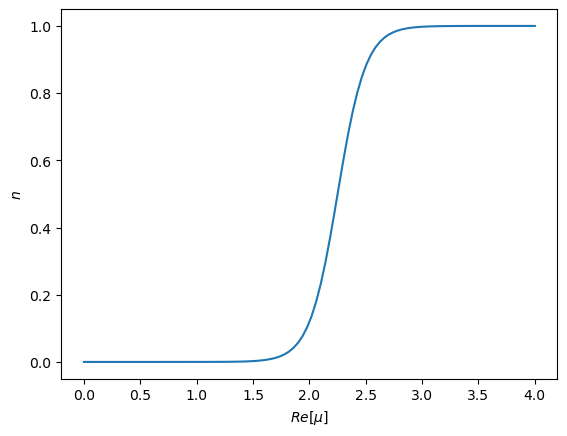

In [4]:
mymu = np.linspace(0., 4., 100)
plt.plot(mymu, n_thirring1d(mymu).real)
plt.ylabel('$n$')
plt.xlabel('$Re[\mu]$')

In [5]:
n_thirring1d_sing()

array([ 2.25019782-3.53429174j,  2.25019782-2.74889357j,
        2.25019782-1.96349541j,  2.25019782-1.17809725j,
        2.25019782-0.39269908j,  2.25019782+0.39269908j,
        2.25019782+1.17809725j,  2.25019782+1.96349541j,
        2.25019782+2.74889357j,  2.25019782+3.53429174j,
       -2.25019782+3.53429174j, -2.25019782+2.74889357j,
       -2.25019782+1.96349541j, -2.25019782+1.17809725j,
       -2.25019782+0.39269908j, -2.25019782-0.39269908j,
       -2.25019782-1.17809725j, -2.25019782-1.96349541j,
       -2.25019782-2.74889357j, -2.25019782-3.53429174j])

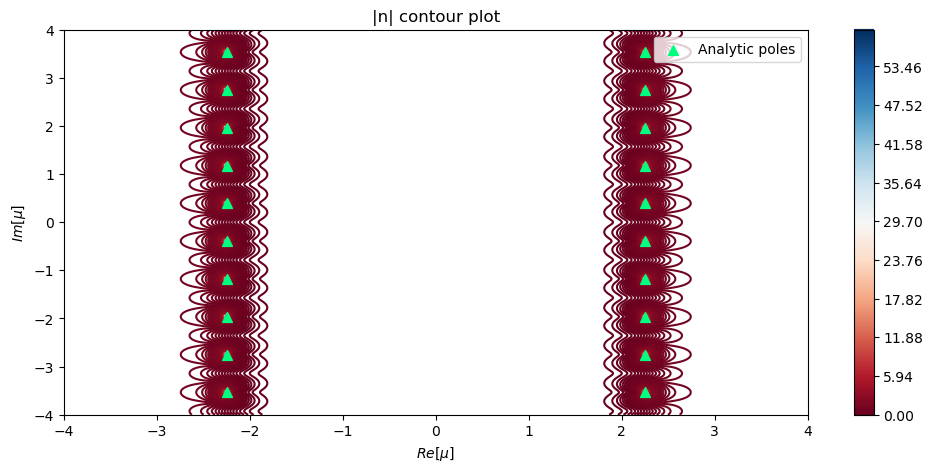

In [6]:
pts = 500
xg = np.linspace(-4, 4, pts)
yg = np.linspace(-4, 4, pts)
Xg, Yg = np.meshgrid(xg, yg)
Zg = Xg + 1.0j*Yg
out = n_thirring1d(Zg)

real_out = out.reshape(Xg.shape)
imag_out = out.imag.reshape(Yg.shape)
abs_out = np.abs(real_out + 1.0j * imag_out)

analytic_sings = n_thirring1d_sing()

plt.figure(figsize=(12, 5))
plt.contour(Xg, Yg, abs_out, levels=1000, cmap='RdBu')
#plt.contourf(Xg, Yg, abs_out, levels=1000, cmap='RdBu')
plt.colorbar()
plt.scatter(analytic_sings.real, analytic_sings.imag, color='springgreen', marker='^', s=50, zorder=2, label='Analytic poles')
plt.xlabel('$Re[\mu]$')
plt.ylabel('$Im[\mu]$')
plt.title('|n| contour plot')
plt.legend()

Text(0.5, 1.0, 'Test data')

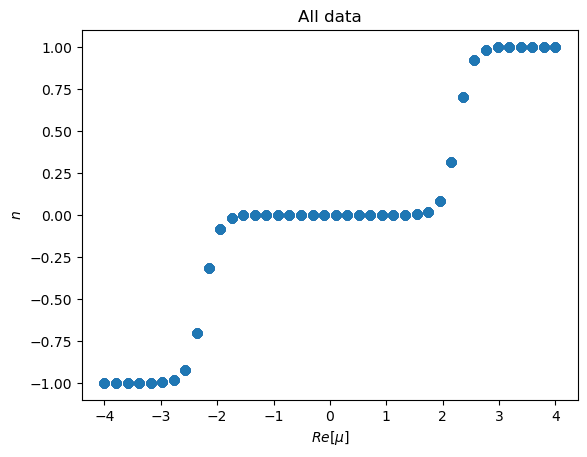

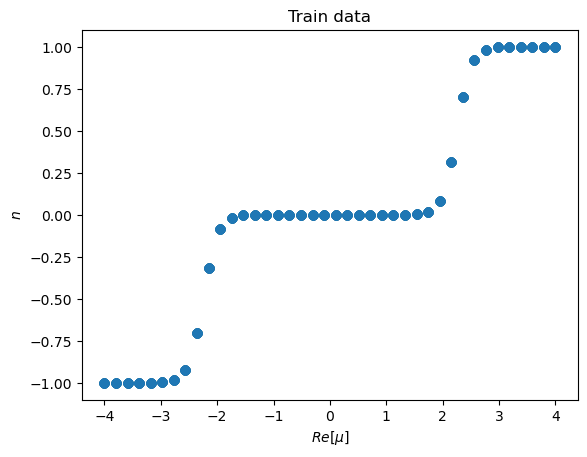

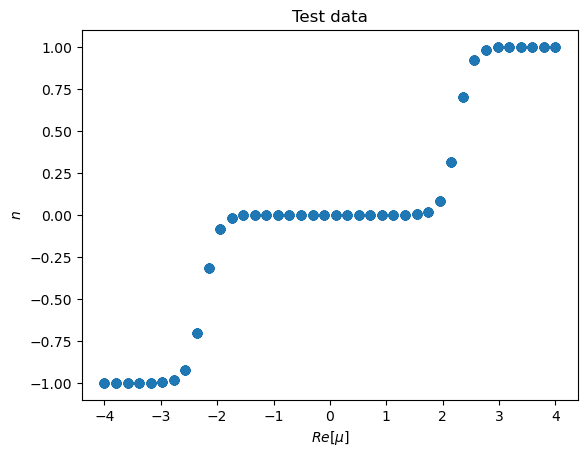

In [7]:
epsilon = 1.0e-6

mu_ = np.linspace(-4.0,4.0,40)
n_ = n_thirring1d(mu_)
dn_ = np.abs(n_) * epsilon

mu_sampled = mu_ 
n_sampled = n_ + dn_*np.random.randn(dn_.size)

for n in np.arange(100):
    mu_sampled = np.append(mu_sampled, mu_)
    n_sampled = np.append(n_sampled, n_ + dn_*np.random.randn(dn_.size))
    
X = np.transpose(np.stack([np.real(mu_sampled), np.imag(mu_sampled)]))
Y = np.transpose(np.stack([np.real(n_sampled), np.imag(n_sampled)]))

plt.figure()
plt.plot(X[:,0], Y[:,0], 'o', ls='')
plt.xlabel('$Re[\mu]$')
plt.ylabel('$n$')
plt.title('All data')

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, shuffle=True, random_state=42)

plt.figure()
plt.plot(X_train[:,0], Y_train[:,0], 'o', ls='')
plt.xlabel('$Re[\mu]$')
plt.ylabel('$n$')
plt.title('Train data')

plt.figure()
plt.plot(X_test[:,0], Y_test[:,0], 'o', ls='')
plt.xlabel('$Re[\mu]$')
plt.ylabel('$n$')
plt.title('Test data')

In [8]:
modelNN_run1 = cpadenn.Models.PadeModel(fugacity=False)
optadam = tf.keras.optimizers.Adam(learning_rate=1.0e-3)

modelNN_run1.compile(optimizer = optadam, loss='mean_squared_error')

EarlyStop = EarlyStopping(monitor='val_loss', patience=100, restore_best_weights=True)

histNN_run1 = modelNN_run1.fit(X_train, Y_train, epochs=2000, batch_size=128, validation_data=(X_test, Y_test), callbacks=[EarlyStop])

print(modelNN_run1.summary())

2025-11-08 11:03:00.800030: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 10s 63ms/step - loss: 3.3045 - val_loss: 1.0672
Epoch 2/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.8935 - val_loss: 0.6476
Epoch 3/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.5432 - val_loss: 0.4661
Epoch 4/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.4027 - val_loss: 0.3386
Epoch 5/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.2995 - val_loss: 0.2523
Epoch 6/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.2231 - val_loss: 0.1924
Epoch 7/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1702 - val_loss: 0.1502
Epoch 8/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1388 - val_loss: 0.1241
Epoch 9/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.1194 - val_loss: 0.1103
Epoch 10/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1078 - val_loss: 0.1023
Epoch 11/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1013 - val_loss: 0.0976
Epoch 12/2000
23/23 ━━━━━━━━━━━━━━━━━━━━

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0764 - val_loss: 0.0765
Epoch 69/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0762 - val_loss: 0.0762
Epoch 70/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0761 - val_loss: 0.0759
Epoch 71/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0756 - val_loss: 0.0756
Epoch 72/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0755 - val_loss: 0.0754
Epoch 73/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0752 - val_loss: 0.0752
Epoch 74/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0749 - val_loss: 0.0747
Epoch 75/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0744 - val_loss: 0.0746
Epoch 76/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0742 - val_loss: 0.0741
Epoch 77/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0740 - val_loss: 0.0738
Epoch 78/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0736 - val_loss: 0.0735
Epoch 79/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13

Epoch 135/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0535 - val_loss: 0.0533
Epoch 136/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0532 - val_loss: 0.0530
Epoch 137/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0529 - val_loss: 0.0526
Epoch 138/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0525 - val_loss: 0.0523
Epoch 139/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0521 - val_loss: 0.0519
Epoch 140/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0518 - val_loss: 0.0518
Epoch 141/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0515 - val_loss: 0.0512
Epoch 142/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0512 - val_loss: 0.0509
Epoch 143/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0508 - val_loss: 0.0505
Epoch 144/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0505 - val_loss: 0.0502
Epoch 145/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0501 - val_loss: 0.0499
Epoch 146/2000
23/23 

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0331 - val_loss: 0.0329
Epoch 202/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0328 - val_loss: 0.0331
Epoch 203/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0329 - val_loss: 0.0332
Epoch 204/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0327 - val_loss: 0.0325
Epoch 205/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0322 - val_loss: 0.0325
Epoch 206/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0321 - val_loss: 0.0317
Epoch 207/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0317 - val_loss: 0.0336
Epoch 208/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0326 - val_loss: 0.0316
Epoch 209/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0314 - val_loss: 0.0310
Epoch 210/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0310 - val_loss: 0.0309
Epoch 211/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0308 - val_loss: 0.0306
Epoch 212/2000
23/23 ━━━━━━━━━━━━━━━

...

 Total params: 452 (1.77 KB)

 Trainable params: 150 (600.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 302 (1.18 KB)

None


In [9]:
modelNN_run2 = cpadenn.Models.PadeModel(fugacity=False)
optadam = tf.keras.optimizers.Adam(learning_rate=1.0e-3)

modelNN_run2.compile(optimizer = optadam, loss='mean_squared_error')

EarlyStop = EarlyStopping(monitor='val_loss', patience=100, restore_best_weights=True)

histNN_run2 = modelNN_run2.fit(X_train, Y_train, epochs=2000, batch_size=128, validation_data=(X_test, Y_test), callbacks=[EarlyStop])

print(modelNN_run2.summary())

Epoch 1/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 10s 61ms/step - loss: 2.9951 - val_loss: 1.2467
Epoch 2/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.9860 - val_loss: 0.5232
Epoch 3/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.4902 - val_loss: 0.3496
Epoch 4/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.3325 - val_loss: 0.2708
Epoch 5/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.2657 - val_loss: 0.2233
Epoch 6/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.2237 - val_loss: 0.1922
Epoch 7/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1936 - val_loss: 0.1711
Epoch 8/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1715 - val_loss: 0.1557
Epoch 9/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1552 - val_loss: 0.1447
Epoch 10/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1472 - val_loss: 0.1359
Epoch 11/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1361 - val_loss: 0.1288
Epoch 12/2000
23/23 ━━━━━━━━━━━━━━━━━━━━

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0833 - val_loss: 0.0831
Epoch 69/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0829 - val_loss: 0.0828
Epoch 70/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0826 - val_loss: 0.0824
Epoch 71/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0823 - val_loss: 0.0821
Epoch 72/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0819 - val_loss: 0.0818
Epoch 73/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0816 - val_loss: 0.0814
Epoch 74/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0813 - val_loss: 0.0811
Epoch 75/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0809 - val_loss: 0.0808
Epoch 76/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0806 - val_loss: 0.0806
Epoch 77/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0804 - val_loss: 0.0802
Epoch 78/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0800 - val_loss: 0.0799
Epoch 79/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14

Epoch 135/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0643 - val_loss: 0.0640
Epoch 136/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0639 - val_loss: 0.0638
Epoch 137/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0637 - val_loss: 0.0635
Epoch 138/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0635 - val_loss: 0.0632
Epoch 139/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0632 - val_loss: 0.0632
Epoch 140/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0631 - val_loss: 0.0627
Epoch 141/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0628 - val_loss: 0.0625
Epoch 142/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0624 - val_loss: 0.0624
Epoch 143/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0622 - val_loss: 0.0620
Epoch 144/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0619 - val_loss: 0.0617
Epoch 145/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0617 - val_loss: 0.0618
Epoch 146/2000
23/23 

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0478 - val_loss: 0.0476
Epoch 202/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0475 - val_loss: 0.0475
Epoch 203/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0474 - val_loss: 0.0473
Epoch 204/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0471 - val_loss: 0.0472
Epoch 205/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0471 - val_loss: 0.0466
Epoch 206/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0466 - val_loss: 0.0467
Epoch 207/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0465 - val_loss: 0.0466
Epoch 208/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0463 - val_loss: 0.0460
Epoch 209/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0459 - val_loss: 0.0457
Epoch 210/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0457 - val_loss: 0.0454
Epoch 211/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0453 - val_loss: 0.0455
Epoch 212/2000
23/23 ━━━━━━━━━━━━━━━

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0332 - val_loss: 0.0329
Epoch 268/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0328 - val_loss: 0.0327
Epoch 269/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0326 - val_loss: 0.0326
Epoch 270/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0325 - val_loss: 0.0321
Epoch 271/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0321 - val_loss: 0.0321
Epoch 272/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0320 - val_loss: 0.0318
Epoch 273/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0317 - val_loss: 0.0315
Epoch 274/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0315 - val_loss: 0.0315
Epoch 275/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0313 - val_loss: 0.0313
Epoch 276/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0311 - val_loss: 0.0309
Epoch 277/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0310 - val_loss: 0.0307
Epoch 278/2000
23/23 ━━━━━━━━━━━━━━━

...

 Total params: 452 (1.77 KB)

 Trainable params: 150 (600.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 302 (1.18 KB)

None


In [10]:
modelNN_baseline1 = cpadenn.Models.BaselineModel1(fugacity=False)
optadam = tf.keras.optimizers.Adam(learning_rate=1.0e-3)

modelNN_baseline1.compile(optimizer = optadam, loss='mean_squared_error')

EarlyStop = EarlyStopping(monitor='val_loss', patience=100, restore_best_weights=True)

histNN_baseline1 = modelNN_baseline1.fit(X_train, Y_train, epochs=2000, batch_size=128, validation_data=(X_test, Y_test), callbacks=[EarlyStop])

print(modelNN_baseline1.summary())

Epoch 1/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - loss: 8.3978 - val_loss: 4.8965
Epoch 2/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 4.1932 - val_loss: 2.8533
Epoch 3/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.6075 - val_loss: 2.0177
Epoch 4/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.8529 - val_loss: 1.4746
Epoch 5/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.3561 - val_loss: 1.1015
Epoch 6/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.0236 - val_loss: 0.8626
Epoch 7/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.8117 - val_loss: 0.7058
Epoch 8/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.6664 - val_loss: 0.5925
Epoch 9/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.5717 - val_loss: 0.5052
Epoch 10/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.4815 - val_loss: 0.4370
Epoch 11/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.4268 - val_loss: 0.3814
Epoch 12/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1321 - val_loss: 0.1327
Epoch 69/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1318 - val_loss: 0.1321
Epoch 70/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1311 - val_loss: 0.1316
Epoch 71/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1300 - val_loss: 0.1311
Epoch 72/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1297 - val_loss: 0.1305
Epoch 73/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1295 - val_loss: 0.1299
Epoch 74/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1290 - val_loss: 0.1294
Epoch 75/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1287 - val_loss: 0.1289
Epoch 76/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1279 - val_loss: 0.1285
Epoch 77/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1276 - val_loss: 0.1280
Epoch 78/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1274 - val_loss: 0.1275
Epoch 79/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12

Epoch 135/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1081 - val_loss: 0.1087
Epoch 136/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1081 - val_loss: 0.1084
Epoch 137/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1074 - val_loss: 0.1082
Epoch 138/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1078 - val_loss: 0.1079
Epoch 139/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1072 - val_loss: 0.1076
Epoch 140/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1066 - val_loss: 0.1074
Epoch 141/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1070 - val_loss: 0.1071
Epoch 142/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1067 - val_loss: 0.1069
Epoch 143/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1063 - val_loss: 0.1065
Epoch 144/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1060 - val_loss: 0.1063
Epoch 145/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1056 - val_loss: 0.1061
Epoch 146/2000
23/23 

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0900 - val_loss: 0.0905
Epoch 202/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0901 - val_loss: 0.0904
Epoch 203/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0897 - val_loss: 0.0899
Epoch 204/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0895 - val_loss: 0.0897
Epoch 205/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0893 - val_loss: 0.0894
Epoch 206/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0890 - val_loss: 0.0892
Epoch 207/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0888 - val_loss: 0.0889
Epoch 208/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0882 - val_loss: 0.0886
Epoch 209/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0882 - val_loss: 0.0883
Epoch 210/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0878 - val_loss: 0.0880
Epoch 211/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0875 - val_loss: 0.0877
Epoch 212/2000
23/23 ━━━━━━━━━━━━━━━

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0732 - val_loss: 0.0732
Epoch 268/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0727 - val_loss: 0.0730
Epoch 269/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0725 - val_loss: 0.0727
Epoch 270/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0723 - val_loss: 0.0726
Epoch 271/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0721 - val_loss: 0.0723
Epoch 272/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0720 - val_loss: 0.0720
Epoch 273/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0715 - val_loss: 0.0719
Epoch 274/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0713 - val_loss: 0.0715
Epoch 275/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0709 - val_loss: 0.0713
Epoch 276/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0710 - val_loss: 0.0710
Epoch 277/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0708 - val_loss: 0.0708
Epoch 278/2000
23/23 ━━━━━━━━━━━━━━━

...

 Total params: 344 (1.35 KB)

 Trainable params: 114 (456.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 230 (924.00 B)

None


In [11]:
modelNN_baseline2 = cpadenn.Models.BaselineModel2(fugacity=False)
optadam = tf.keras.optimizers.Adam(learning_rate=1.0e-3)

modelNN_baseline2.compile(optimizer = optadam, loss='mean_squared_error')

EarlyStop = EarlyStopping(monitor='val_loss', patience=100, restore_best_weights=True)

histNN_baseline2 = modelNN_baseline2.fit(X_train, Y_train, epochs=2000, batch_size=128, validation_data=(X_test, Y_test), callbacks=[EarlyStop])

print(modelNN_baseline2.summary())

Epoch 1/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 7s 58ms/step - loss: 7.4233 - val_loss: 3.7223
Epoch 2/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.9525 - val_loss: 1.5744
Epoch 3/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.3629 - val_loss: 0.9564
Epoch 4/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.9039 - val_loss: 0.7990
Epoch 5/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.7742 - val_loss: 0.7315
Epoch 6/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.7173 - val_loss: 0.6745
Epoch 7/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.6559 - val_loss: 0.6198
Epoch 8/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.6030 - val_loss: 0.5653
Epoch 9/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.5417 - val_loss: 0.5125
Epoch 10/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.4940 - val_loss: 0.4628
Epoch 11/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.4468 - val_loss: 0.4144
Epoch 12/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1329 - val_loss: 0.1345
Epoch 69/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1324 - val_loss: 0.1341
Epoch 70/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1325 - val_loss: 0.1338
Epoch 71/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1326 - val_loss: 0.1334
Epoch 72/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1316 - val_loss: 0.1330
Epoch 73/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1312 - val_loss: 0.1327
Epoch 74/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1310 - val_loss: 0.1323
Epoch 75/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1301 - val_loss: 0.1319
Epoch 76/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1303 - val_loss: 0.1315
Epoch 77/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1296 - val_loss: 0.1312
Epoch 78/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1304 - val_loss: 0.1308
Epoch 79/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13

Epoch 135/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1128 - val_loss: 0.1133
Epoch 136/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1123 - val_loss: 0.1131
Epoch 137/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1118 - val_loss: 0.1127
Epoch 138/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1119 - val_loss: 0.1124
Epoch 139/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1117 - val_loss: 0.1121
Epoch 140/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1116 - val_loss: 0.1118
Epoch 141/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1112 - val_loss: 0.1115
Epoch 142/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1107 - val_loss: 0.1112
Epoch 143/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1104 - val_loss: 0.1109
Epoch 144/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1101 - val_loss: 0.1106
Epoch 145/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1098 - val_loss: 0.1103
Epoch 146/2000
23/23 

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0917 - val_loss: 0.0918
Epoch 202/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0913 - val_loss: 0.0915
Epoch 203/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0907 - val_loss: 0.0911
Epoch 204/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0905 - val_loss: 0.0908
Epoch 205/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0897 - val_loss: 0.0906
Epoch 206/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0896 - val_loss: 0.0902
Epoch 207/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0896 - val_loss: 0.0899
Epoch 208/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0894 - val_loss: 0.0895
Epoch 209/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0888 - val_loss: 0.0893
Epoch 210/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0887 - val_loss: 0.0888
Epoch 211/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0884 - val_loss: 0.0885
Epoch 212/2000
23/23 ━━━━━━━━━━━━━━━

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0692 - val_loss: 0.0696
Epoch 268/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0690 - val_loss: 0.0691
Epoch 269/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0681 - val_loss: 0.0688
Epoch 270/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0682 - val_loss: 0.0686
Epoch 271/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0680 - val_loss: 0.0682
Epoch 272/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0677 - val_loss: 0.0679
Epoch 273/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0674 - val_loss: 0.0677
Epoch 274/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0674 - val_loss: 0.0675
Epoch 275/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0672 - val_loss: 0.0669
Epoch 276/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0665 - val_loss: 0.0664
Epoch 277/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0660 - val_loss: 0.0664
Epoch 278/2000
23/23 ━━━━━━━━━━━━━━━

...

 Total params: 464 (1.82 KB)

 Trainable params: 154 (616.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 310 (1.21 KB)

None


Text(0, 0.5, 'Loss')

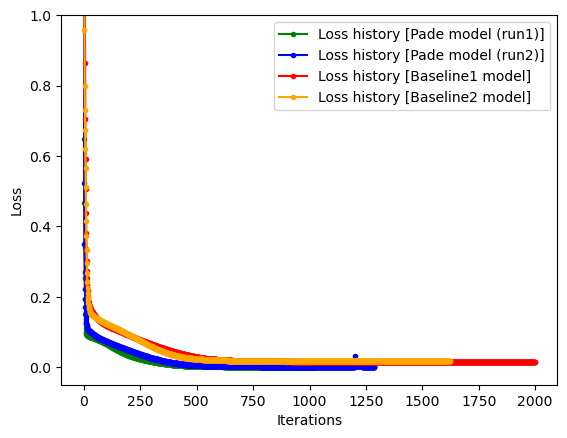

In [12]:
loss_NN_run1 = histNN_run1.history['val_loss']
loss_NN_run2 = histNN_run2.history['val_loss']
loss_NN_baseline1 = histNN_baseline1.history['val_loss']
loss_NN_baseline2 = histNN_baseline2.history['val_loss']

plt.plot(loss_NN_run1, label='Loss history [Pade model (run1)]', marker='.', color='green')
plt.plot(loss_NN_run2, label='Loss history [Pade model (run2)]', marker='.', color='blue')
plt.plot(loss_NN_baseline1, label='Loss history [Baseline1 model]', marker='.', color='red')
plt.plot(loss_NN_baseline2, label='Loss history [Baseline2 model]', marker='.', color='orange')
plt.legend()
plt.ylim([-0.05,1])
plt.xlabel('Iterations')
plt.ylabel('Loss')

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step


Text(0, 0.5, '$n$')

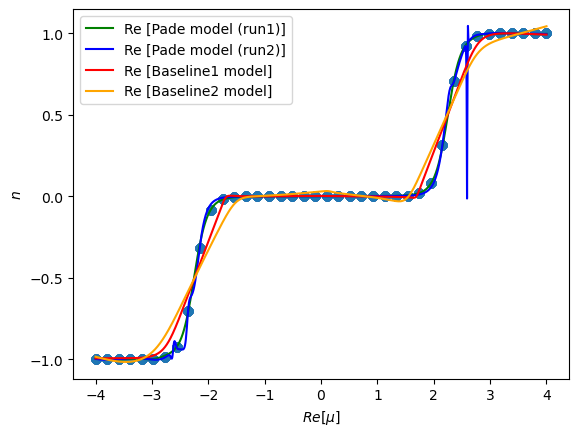

In [13]:
mu_pred = np.linspace(-4,4,1000)

X_pred = np.transpose(np.stack([np.real(mu_pred), np.imag(mu_pred)]))
Y_pred_NN_run1 = modelNN_run1.predict(X_pred)
Y_pred_NN_run2 = modelNN_run2.predict(X_pred)
Y_pred_NN_baseline1 = modelNN_baseline1.predict(X_pred)
Y_pred_NN_baseline2 = modelNN_baseline2.predict(X_pred)

plt.figure()
plt.plot(X[:,0], Y[:,0], 'o', ls='')
plt.plot(X_pred[:,0], Y_pred_NN_run1[:,0], color='green', label='Re [Pade model (run1)]')
plt.plot(X_pred[:,0], Y_pred_NN_run2[:,0], color='blue', label='Re [Pade model (run2)]')
plt.plot(X_pred[:,0], Y_pred_NN_baseline1[:,0], color='red', label='Re [Baseline1 model]')
plt.plot(X_pred[:,0], Y_pred_NN_baseline2[:,0], color='orange', label='Re [Baseline2 model]')
plt.legend()
plt.xlabel('$Re[\mu]$')
plt.ylabel('$n$')

5000/5000 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step


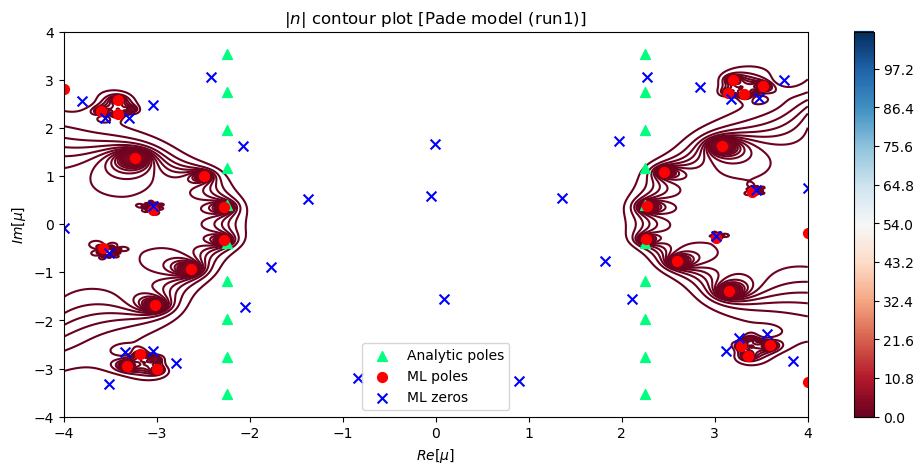

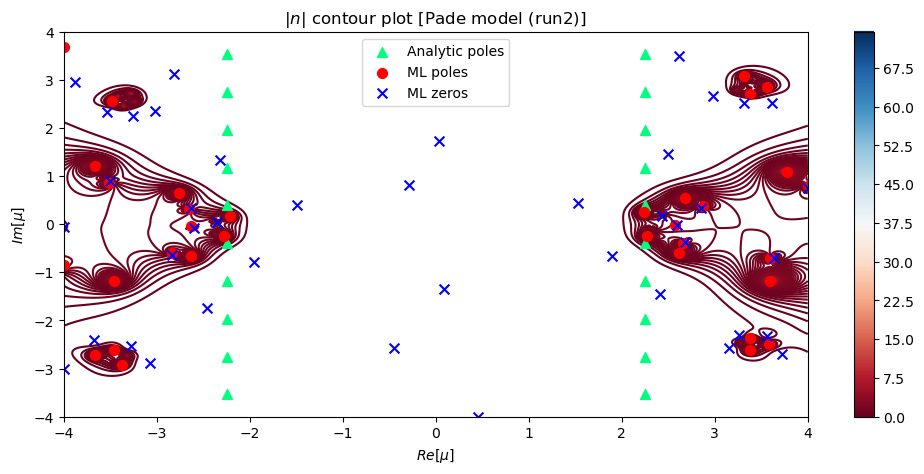

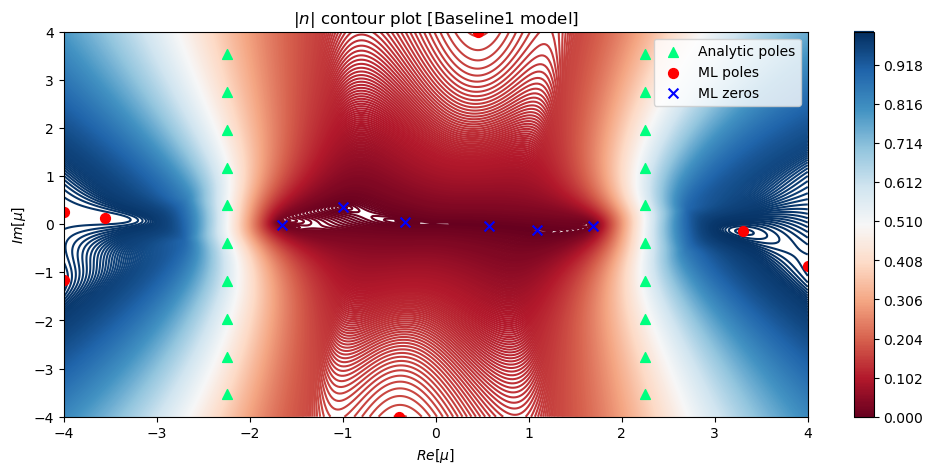

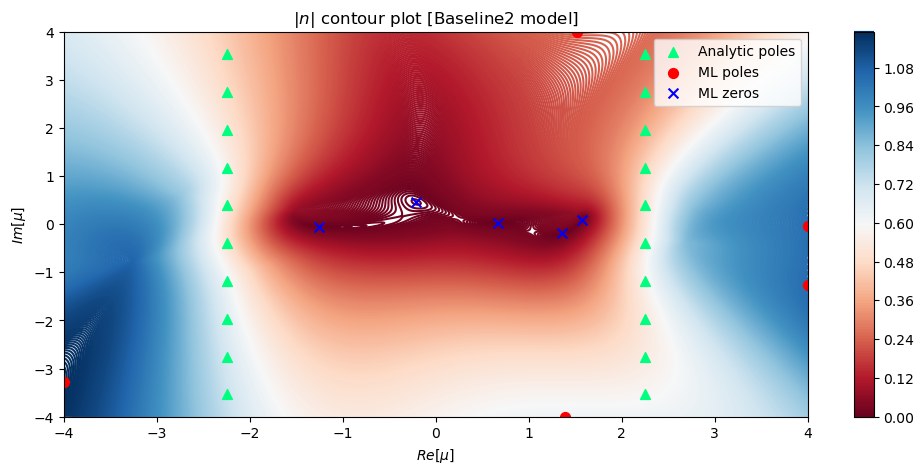

In [14]:
models = [modelNN_run1, modelNN_run2, modelNN_baseline1, modelNN_baseline2]
names = ['Pade model (run1)', 'Pade model (run2)', 'Baseline1 model', 'Baseline2 model']
for n in np.arange(4):
    pts = 400
    xg = np.linspace(-4, 4, pts)
    yg = np.linspace(-4, 4, pts)
    Xg, Yg = np.meshgrid(xg, yg)
    Zg = np.stack([Xg.ravel(), Yg.ravel()], axis=-1).astype(np.float32)
    out = models[n].predict(Zg)

    real_out = out[:, 0].reshape(Xg.shape)
    imag_out = out[:, 1].reshape(Yg.shape)
    abs_out = np.abs(real_out + 1.0j * imag_out)

    poles = cpadenn.Utils.FindLocMax(Xg, Yg, abs_out)
    zeros = cpadenn.Utils.FindLocMax(Xg, Yg, 1.0/abs_out)

    analytic_sings = n_thirring1d_sing()

    plt.figure(figsize=(12, 5))
    plt.contour(Xg, Yg, abs_out, levels=800, cmap='RdBu')
    #plt.contourf(Xg, Yg, abs_out, levels=800, cmap='RdBu')
    plt.colorbar()
    plt.scatter(analytic_sings.real, analytic_sings.imag, color='springgreen', marker='^', s=50, zorder=2, label='Analytic poles')
    plt.scatter(poles[:,0], poles[:,1], color='red', marker='o', s=50, zorder=2, label='ML poles')
    plt.scatter(zeros[:,0], zeros[:,1], color='blue', marker='x', s=50, zorder=2, label='ML zeros')
    plt.xlabel('$Re[\mu]$')
    plt.ylabel('$Im[\mu]$')
    plt.title(f"$|n|$ contour plot [{names[n]}]")
    plt.legend()